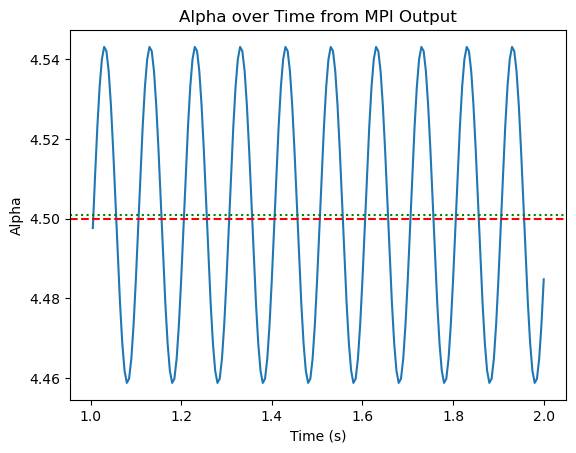

amplitude, period: (np.float64(0.010000000000000004), np.float64(0.10000000000000002))


In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from solver import get_homogeneous_solution

def get_params_from_index(index, amplitudes, periods):
    n_amp = len(amplitudes)
    n_period = len(periods)
    i = index // n_period
    j = index % n_period
    return amplitudes[i], periods[j]

def get_range(x_min, x_max, n_x):
    return np.exp(np.linspace(np.log(x_min), np.log(x_max), n_x))

amplitudes = get_range(0.01, 0.5, 4)
periods = get_range(0.1, 10.0, 8)

index = 0

filename = f"timeseries/mpi_output_index{index}.txt"
data = np.loadtxt(filename, delimiter=";")
times = data[:,0]
alphas = data[:,1]
plt.plot(times, alphas)
plt.axhline(10*(1-get_homogeneous_solution(0, [10.0, 10.0, 0.1])), color='red', linestyle='--', label='Homogeneous Solution')
plt.axhline(np.mean(alphas), color='green', linestyle=':', label='Mean Alpha')
plt.xlabel("Time (s)")
plt.ylabel("Alpha")
plt.title("Alpha over Time from MPI Output")
plt.show()

print("amplitude, period:", get_params_from_index(index, amplitudes, periods))


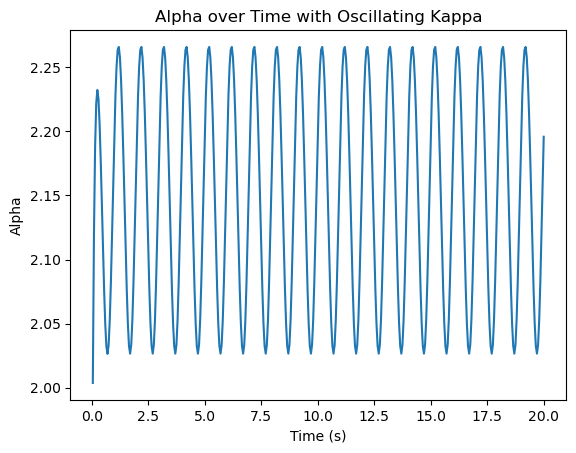

In [10]:
import numpy as np 
import matplotlib.pyplot as plt
import functools
from PNAS_REVIEW.codebase.temporal.temporal_solver import TemporalSolver 
from constants import TemporalConstants, general_delta, general_kappa, general_oscillator

case = "E"

tc = TemporalConstants()
params = tc.get_case_params(case)
amplitude = 0.1 
period = 1.0 

timing = (0.0, tc.periods_to_run * period, tc.fraction_of_period * period)

def osc_kappa(x: np.ndarray, t: float) -> np.ndarray:
    update_osc = functools.partial(general_oscillator, amplitude=amplitude, period=period)
    return general_kappa(x, t) * update_osc(x, t) 

solver = TemporalSolver(params=params,
                        timing=timing,
                        animate=True,
                        animation_name="testK.gif",
                        update_delta=general_delta,
                        update_kappa=osc_kappa)
times, alphas = solver.solve()
plt.plot(times, alphas)
plt.xlabel("Time (s)")
plt.ylabel("Alpha")
plt.title("Alpha over Time with Oscillating Kappa")
plt.show()

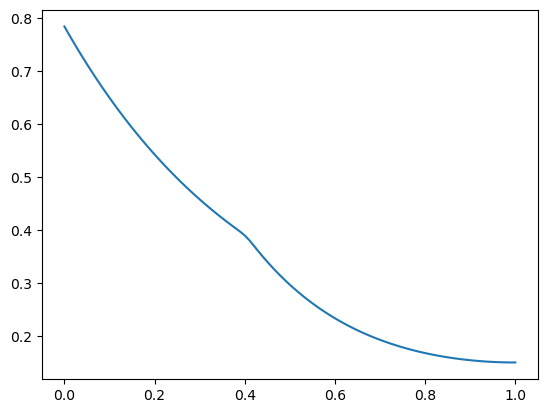

In [12]:
import sys 
sys.path.append("../steady_state")
import steady_solver

solver = steady_solver.SteadySolver(params,
                                    delta = functools.partial(general_delta, t=0.0),
                                    kappa = functools.partial(general_kappa, t=0.0))
domain, solution = solver.solve()
plt.plot(domain, solution)